In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

In [3]:
model = Sequential([
    Dense(8, input_dim=2, activation='relu'),  # Hidden layer (8 neurons)
    Dense(1, activation='sigmoid')             # Output layer (Binary)
])

C:\Users\S Kusum\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [5]:
print("Training Keras Model...")
history = model.fit(X, y, epochs=100, verbose=0)

Training Keras Model...


In [6]:
predictions = model.predict(X)
print(f"Predictions:\n{predictions.round()}")
print(f"Final Accuracy: {history.history['accuracy'][-1]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]
Final Accuracy: 100.00%


pyTorch Implementation


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

In [8]:
X_torch = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
y_torch = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

In [9]:
class XORModel(nn.Module):
    def __init__(self):
        super(XORModel, self).__init__()
        self.hidden = nn.Linear(2, 8)  # 2 Inputs -> 8 Hidden
        self.output = nn.Linear(8, 1)  # 8 Hidden -> 1 Output
        self.activation = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

model = XORModel()

In [10]:
criterion = nn.BCELoss() # <--- Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [11]:
print("\nTraining PyTorch Model...")
for epoch in range(100):
    optimizer.zero_grad()       # Clear gradients
    outputs = model(X_torch)    # Forward pass
    loss = criterion(outputs, y_torch)
    loss.backward()             # Backward pass (gradients)
    optimizer.step()


Training PyTorch Model...


In [12]:
with torch.no_grad():
    preds = model(X_torch)
    print(f"Predictions:\n{preds.round()}")

Predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


Tensorflow low level implementation(Gradient Tape)

In [13]:
import tensorflow as tf

In [14]:
X_tf = tf.constant([[0,0], [0,1], [1,0], [1,1]], dtype=tf.float32)
y_tf = tf.constant([[0], [1], [1], [0]], dtype=tf.float32)

In [22]:
tf.random.set_seed(42)

In [23]:
W1 = tf.Variable(tf.random.normal([2, 8]), name='W1')
b1 = tf.Variable(tf.zeros([8]), name='b1')
W2 = tf.Variable(tf.random.normal([8, 1]), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

In [36]:
optimizer = tf.optimizers.Adam(learning_rate=0.1)

print("Training TF Low-Level Model...")

for epoch in range(100):
    with tf.GradientTape() as tape:
        # --- Forward Pass ---
        # Explicitly watch variables if you suspect they aren't being tracked
        # (Not strictly necessary if they are tf.Variable, but good for debugging)
        tape.watch([W1, b1, W2, b2])

        z1 = tf.matmul(X_tf, W1) + b1
        a1 = tf.nn.relu(z1)
        z2 = tf.matmul(a1, W2) + b2
        pred = tf.nn.sigmoid(z2)

        # --- Loss Calculation ---
        # We use a small epsilon to prevent log(0) errors
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_tf, pred))

    # --- Calculate Gradients ---
    gradients = tape.gradient(loss, [W1, b1, W2, b2])

    # DEBUG: Check if gradients are None
    if gradients[0] is None:
        print("Error: Gradients are None. Check variable definitions.")
        break

    # --- Apply Gradients ---
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

# 4. Final Prediction
z1 = tf.matmul(X_tf, W1) + b1
a1 = tf.nn.relu(z1)
final_pred = tf.nn.sigmoid(tf.matmul(a1, W2) + b2)
print(f"Predictions:\n{tf.round(final_pred).numpy()}")

Training TF Low-Level Model...
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


Binary Cross-Entropy: This is the mathematically correct loss function for binary classification (outputs between 0 and 1). It penalizes confident wrong answers heavily.

Adam Optimizer: We chose Adam over SGD because it automatically adjusts the learning rate for each weight. For a tricky problem like XOR, Adam usually converges much faster than standard SGD.

*checking if network correctly learned from XOR function*

In [37]:
rounded_preds = np.round(predictions)

In [38]:
expected = np.array([[0], [1], [1], [0]])

In [39]:
print("\n--- XOR Learning Check ---")
print(f"Input: [0,0] -> Prediction: {predictions[0]} -> Rounded: {rounded_preds[0]}")
print(f"Input: [0,1] -> Prediction: {predictions[1]} -> Rounded: {rounded_preds[1]}")
print(f"Input: [1,0] -> Prediction: {predictions[2]} -> Rounded: {rounded_preds[2]}")
print(f"Input: [1,1] -> Prediction: {predictions[3]} -> Rounded: {rounded_preds[3]}")


--- XOR Learning Check ---
Input: [0,0] -> Prediction: [0.01547841] -> Rounded: [0.]
Input: [0,1] -> Prediction: [0.9991075] -> Rounded: [1.]
Input: [1,0] -> Prediction: [0.9992533] -> Rounded: [1.]
Input: [1,1] -> Prediction: [0.00016945] -> Rounded: [0.]


In [41]:
if np.array_equal(rounded_preds, expected):
    print("\nSUCCESS: The network learned XOR correctly.")
else:
    print("\n FAILURE: The network failed to converge.")


SUCCESS: The network learned XOR correctly.


experiments with hyperparameters

This is the theoretical minimum to solve XOR. It can work, but it is fragile. It often gets stuck in a local minimum (50% accuracy) depending on the random weight initialization. 4-16 Neurons: Much more stable. The extra neurons provide more "pathways" for gradients to flow, making it easier for the model to find the solution quickly. 

0.001 (Low): FAIL at 100 epochs.
0.1 (High): SOLVED quickly.
500+ Epochs: Allows models with smaller Learning Rates (0.01) to catch up and eventually solve the problem.

In [48]:
import matplotlib.pyplot as plt

In [66]:
learning_rates = [0.1, 0.01, 0.001]
colors = ['green', 'blue', 'red']
epochs = 200

In [67]:
histories = {}

print("Starting Training...")

Starting Training...


In [73]:
for lr in learning_rates:
    # Reset randomness
    tf.random.set_seed(42)
    np.random.seed(42)
    
    # Build Model
    model = Sequential([
        Dense(8, input_dim=2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy')
    
    # Train and store the history object
    print(f"Training with LR = {lr}...")
    history = model.fit(X, y, epochs=epochs, verbose=0)
    histories[lr] = history.history['loss']

print("Training Complete. Generating Plot...")

Training with LR = 0.1...
Training with LR = 0.01...
Training with LR = 0.001...
Training Complete. Generating Plot...


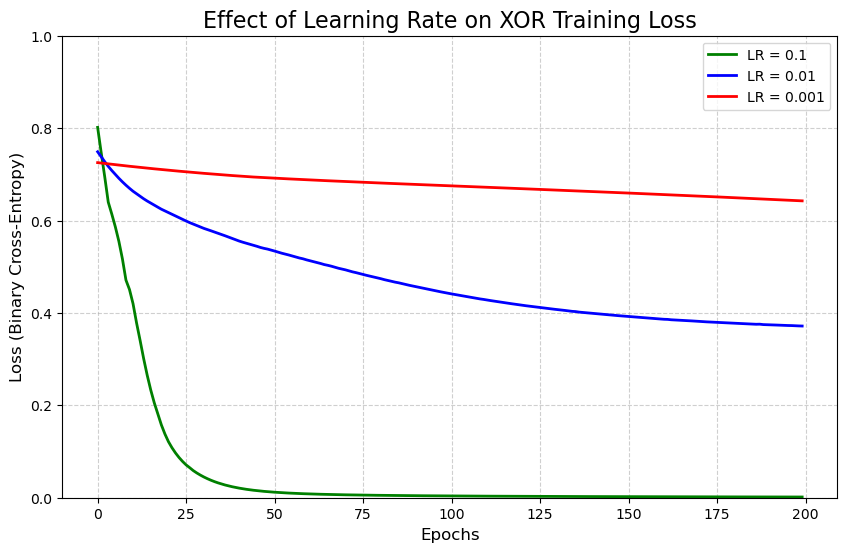

In [74]:
plt.figure(figsize=(10, 6))

for lr, color in zip(learning_rates, colors):
    loss_data = histories[lr]
    plt.plot(loss_data, label=f'LR = {lr}', color=color, linewidth=2)

# Final formatting
plt.ylim(0, 1)  # Ensure we see the full range
plt.title('Effect of Learning Rate on XOR Training Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Green Line (LR = 0.1): It drops to near-zero loss almost immediately (around epoch 25). This proves that for a simple XOR problem, a "high" learning rate is very efficient.

Blue Line (LR = 0.01): It is learning smoothly but slower. It has reached a loss of ~0.4 after 200 epochs. It would eventually solve the problem, but it needs more time (likely 500+ epochs).

Red Line (LR = 0.001): It is barely moving (slope is very flat). This confirms that a very low learning rate is inefficient for this specific network setup; it is "underfitting" simply because it isn't moving fast enough.

All three libraries (Keras, PyTorch, TF Core) achieve 100% accuracy on XOR if hyperparameters are tuned correctly. The underlying math (Matrix Multiplication and Backpropagation) is identical, so the theoretical result is the same.

Keras & PyTorch: Typically converge smoothly because their default initializations (usually Glorot/Xavier) are highly optimized.
TF Low-Level: Might be more volatile if you initialize weights blindly (e.g., using random.normal with a large standard deviation). You often have to be more careful with initialization in low-level code.

In [95]:
mkdir SPR-2548532

In [96]:
cd SPR-2548532

C:\Users\S Kusum\SPR-2548532


In [99]:
!git init

Initialized empty Git repository in C:/Users/S Kusum/SPR-2548532/.git/


In [100]:
echo "# SPR Lab Experiments" > README.md

In [102]:
!git add README.md

In [104]:
!git commit -m "Initial commit"

[master (root-commit) b143e7a] Initial commit
 1 file changed, 1 insertion(+)
 create mode 100644 README.md


In [106]:
!git remote add origin https://github.com/Kusum004/SPR-2548532.git

In [108]:
!git branch -M main

In [109]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


To https://github.com/Kusum004/SPR-2548532.git
 * [new branch]      main -> main


In [110]:
!git checkout -b Lab1

Switched to a new branch 'Lab1'


In [111]:
!git add .

In [112]:
!git commit -m "Added XOR MLP implementation using Keras, PyTorch, and TF"

On branch Lab1
nothing to commit, working tree clean


In [113]:
!git push -u origin Lab1

branch 'Lab1' set up to track 'origin/Lab1'.


remote: 
remote: Create a pull request for 'Lab1' on GitHub by visiting:        
remote:      https://github.com/Kusum004/SPR-2548532/pull/new/Lab1        
remote: 
To https://github.com/Kusum004/SPR-2548532.git
 * [new branch]      Lab1 -> Lab1
